Machine Learning Project 2 - Customer_Churn_Risk Dataset

In [4]:
# Goal - Predict whether a customer will churn using Logistic Regression

# Target = 0 --> Customer stays
# Target = 1 --> Customer churns

# Workflow: Load - Inspect - Validate - Explore - Split - Scale - Train - Predict - Evaluate - Interpret

In [5]:
# Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [6]:
# Import and mount drive

from google.colab import drive

drive.mount('/content/drive')

# Define the path of your dataset

file_path = "/content/drive/My Drive/LearnDepth M.L Projects/M.L 2 - Customer Churn Prediction/Dataset_01_Customer_Churn_Risk.csv"

Mounted at /content/drive


In [7]:
# Load the data/CSV file

data = pd.read_csv(file_path)

# You need a dataframe.
# CSV files are automatically loaded as Dataframes in Python using the Pandas library when the pd.read_csv() function is called.

In [8]:
data

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
0,52,54.79,7,10.66,2,12,0
1,11,167.15,4,46.99,3,37,1
2,2,184.92,3,65.38,7,35,1
3,39,271.21,2,22.19,4,10,0
4,22,66.33,5,46.77,3,33,1
...,...,...,...,...,...,...,...
995,21,84.05,3,33.59,4,10,1
996,22,275.85,1,53.71,3,19,1
997,7,113.44,0,72.04,1,48,1
998,21,242.63,4,53.20,5,39,0


In [9]:
# Print 1st 5 rows

data.head()

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
0,52,54.79,7,10.66,2,12,0
1,11,167.15,4,46.99,3,37,1
2,2,184.92,3,65.38,7,35,1
3,39,271.21,2,22.19,4,10,0
4,22,66.33,5,46.77,3,33,1


In [10]:
# Print last 5 rows

data.tail()

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
995,21,84.05,3,33.59,4,10,1
996,22,275.85,1,53.71,3,19,1
997,7,113.44,0,72.04,1,48,1
998,21,242.63,4,53.20,5,39,0
999,10,246.73,2,45.37,4,58,0


In [11]:
# Shape of the dataset

print(data.shape)
print("No. of Rows & Columns:", data.shape)

(1000, 7)
No. of Rows & Columns: (1000, 7)


In [12]:
# Nmaes of columns

print(data.columns.to_list())

['tenure_months', 'monthly_charges', 'support_tickets', 'avg_session_minutes', 'late_payments', 'contract_months', 'target']


In [13]:
# Rename columns

data.rename(columns = {"tenure_months": "Tenure_Months", "monthly_charges": "Monthly_Charges", "support_tickets": "Support_Tickets",
                       "avg_session_minutes": "Avg_Session_Mins", "late_payments": "Late_Payments", "contract_months": "Contract_Months",
                       "target": "Target"}, inplace = True)

In [14]:
data

,Tenure_Months,Monthly_Charges,Support_Tickets,Avg_Session_Mins,Late_Payments,Contract_Months,Target
0,52,54.79,7,10.66,2,12,0
1,11,167.15,4,46.99,3,37,1
2,2,184.92,3,65.38,7,35,1
3,39,271.21,2,22.19,4,10,0
4,22,66.33,5,46.77,3,33,1
...,...,...,...,...,...,...,...
995,21,84.05,3,33.59,4,10,1
996,22,275.85,1,53.71,3,19,1
997,7,113.44,0,72.04,1,48,1
998,21,242.63,4,53.20,5,39,0


In [15]:
# Names of new columns now -

print(data.columns.to_list())

['Tenure_Months', 'Monthly_Charges', 'Support_Tickets', 'Avg_Session_Mins', 'Late_Payments', 'Contract_Months', 'Target']


In [16]:
# Types of data involved

print(data.dtypes)

Tenure_Months         int64
Monthly_Charges     float64
Support_Tickets       int64
Avg_Session_Mins    float64
Late_Payments         int64
Contract_Months       int64
Target                int64
dtype: object


In [17]:
# Numerical_Columns/ Independant_Variables = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]
# Categorical_Columns/ Dependant_Variable = ["Target"]

# All independant variables are numerical, which makes this dataset suitable for basic numerical ML.

In [18]:
# Basic information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tenure_Months     1000 non-null   int64  
 1   Monthly_Charges   1000 non-null   float64
 2   Support_Tickets   1000 non-null   int64  
 3   Avg_Session_Mins  1000 non-null   float64
 4   Late_Payments     1000 non-null   int64  
 5   Contract_Months   1000 non-null   int64  
 6   Target            1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


In [19]:
# Basic statistics

data.describe()

,Tenure_Months,Monthly_Charges,Support_Tickets,Avg_Session_Mins,Late_Payments,Contract_Months,Target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,30.121000,182.738270,3.129000,35.511450,3.081000,30.234000,0.50000
std,17.216526,144.743232,1.772428,19.954864,1.763959,17.254186,0.50025
min,1.000000,16.810000,0.000000,2.000000,0.000000,1.000000,0.00000
25%,15.000000,89.610000,2.000000,20.152500,2.000000,15.000000,0.00000
50%,30.000000,144.690000,3.000000,35.085000,3.000000,31.000000,0.50000
75%,45.000000,232.287500,4.000000,49.690000,4.000000,45.000000,1.00000
max,60.000000,1530.680000,11.000000,103.350000,10.000000,60.000000,1.00000


In [20]:
# The "Target" is what the model will predict.

In [21]:
# Missing values

data.isnull()

,Tenure_Months,Monthly_Charges,Support_Tickets,Avg_Session_Mins,Late_Payments,Contract_Months,Target
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False


In [22]:
# Total missing values in each column

print(data.isnull().sum())

Tenure_Months       0
Monthly_Charges     0
Support_Tickets     0
Avg_Session_Mins    0
Late_Payments       0
Contract_Months     0
Target              0
dtype: int64


In [23]:
# Total missing values

print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [24]:
# Check duplicate rows

# Check whether rows in your DataFrame are duplicates

print(data.duplicated().sum())
print("Total No. of duplicate rows:", data.duplicated().sum())

0
Total No. of duplicate rows: 0


In [25]:
# Identify invalid values (i.e) in columns --> "Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"

In [26]:
# Numerical_Columns/ Independant_Variables/ Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]
# Categorical_Columns/ Dependant Variable = ["Target"]

Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]

for column in Feature_Columns:
  print(column, "-ve values:", (data[column] < 0).sum())

Tenure_Months -ve values: 0
Monthly_Charges -ve values: 0
Support_Tickets -ve values: 0
Avg_Session_Mins -ve values: 0
Late_Payments -ve values: 0
Contract_Months -ve values: 0


In [27]:
# Check Categorical_Columns/ Dependant_Variable (i.e) ["Target"]

# Get its unique values

print(data["Target"].unique())

[0 1]


In [28]:
# Get No. of values in Target

print("Target values:", data["Target"].value_counts().sort_index())

Target values: Target
0    500
1    500
Name: count, dtype: int64


In [29]:
# The target is already valid:

# 0 = No Churn
# 1 = Churn

In [30]:
# Percentage of Target distribution

print("Percentages of Target distribution:", (data["Target"].value_counts(normalize = True) * 100).round(2))

Percentages of Target distribution: Target
0    50.0
1    50.0
Name: proportion, dtype: float64


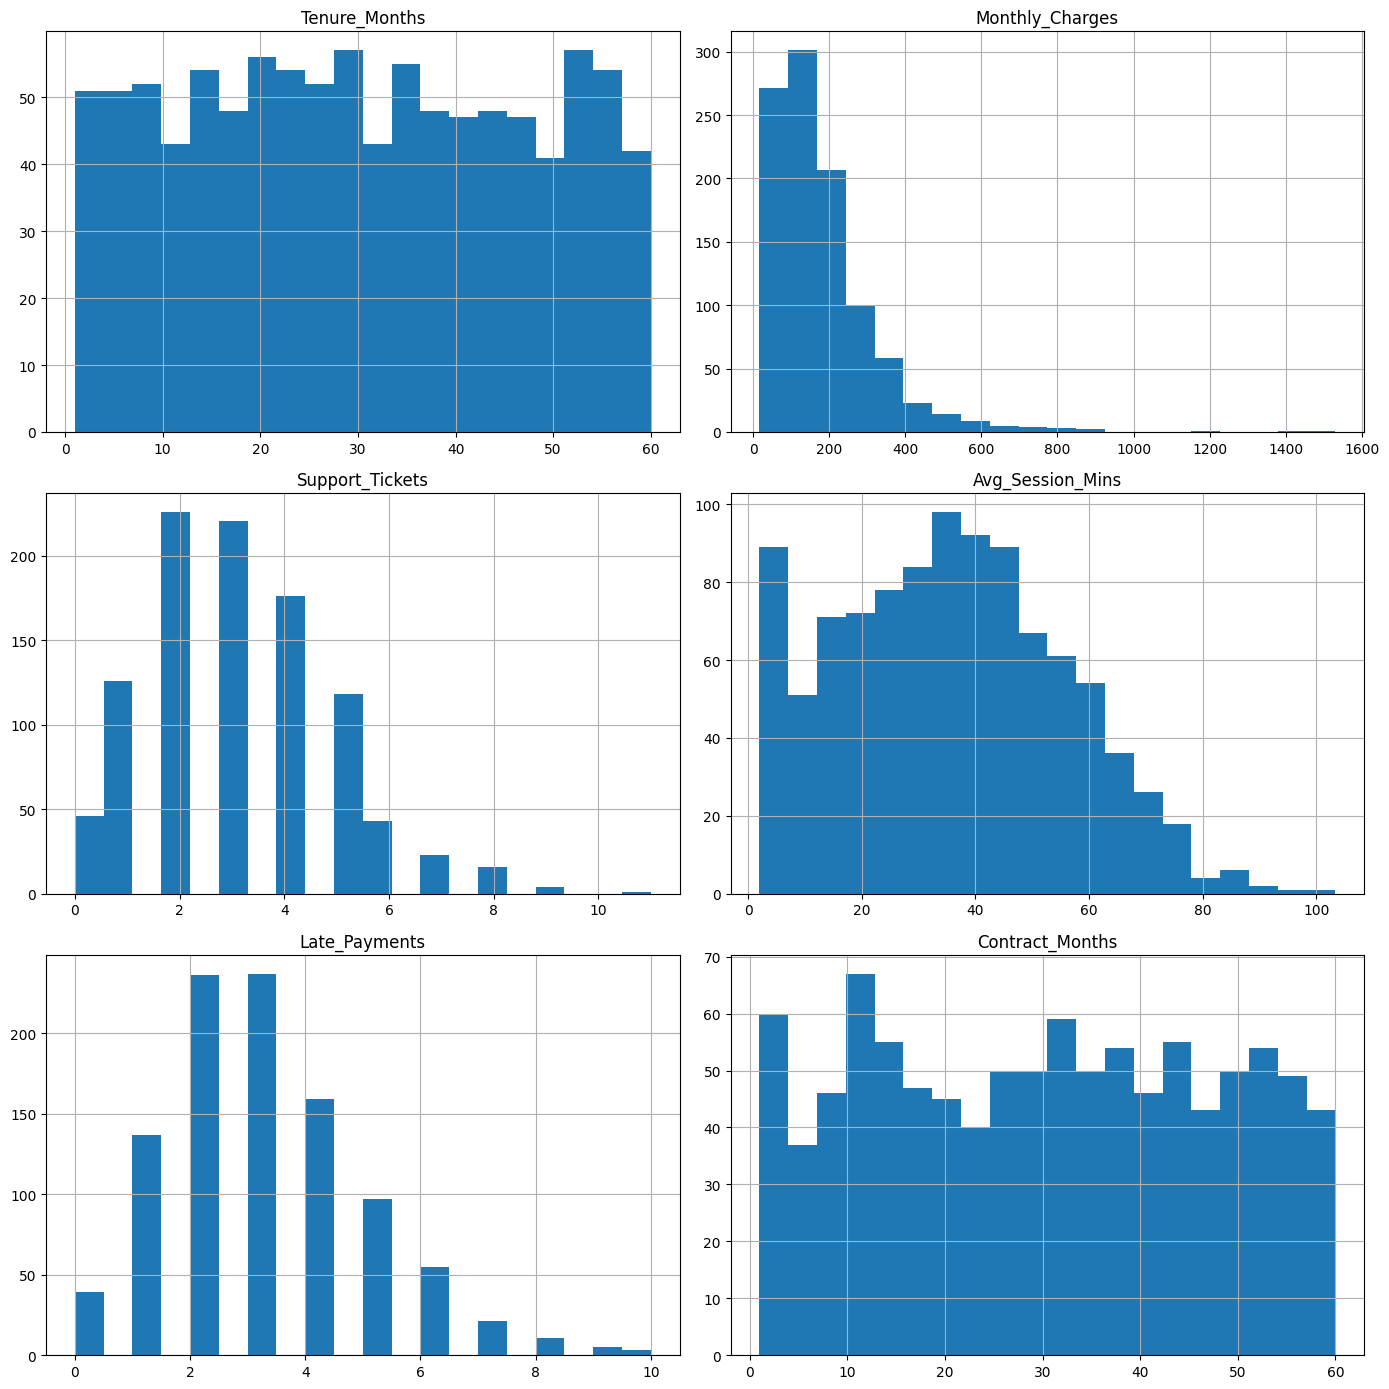

In [31]:
# Visualizations

# Grouped Histograms

Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]

data[Feature_Columns].hist(figsize = (14,14), bins = 20)

plt.tight_layout()
plt.show()

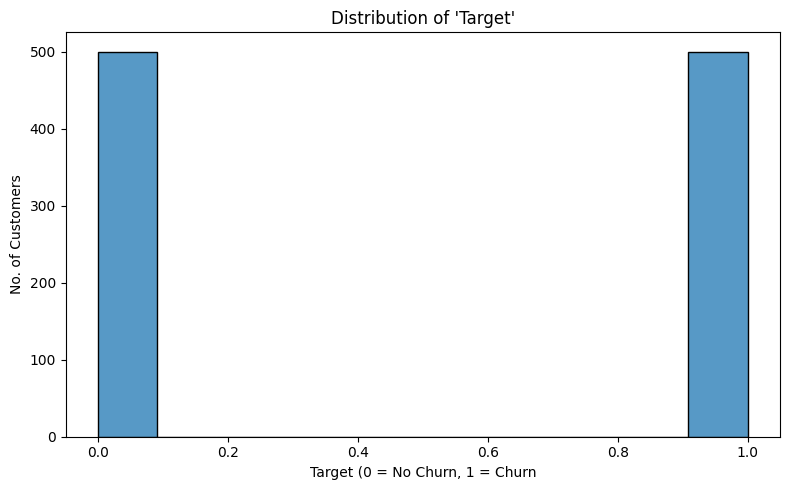

In [32]:
# Histogram of 'Target'

# Categorical_Columns/ Dependant Variable = ["Target"]

Categorical_Columns = ["Target"]

for column in Categorical_Columns:

  plt.figure(figsize = (8,5))

  sns.histplot(data = data, x = column)

  plt.title(f"Distribution of 'Target'")
  plt.xlabel("Target (0 = No Churn, 1 = Churn")
  plt.ylabel("No. of Customers")

  plt.tight_layout()
  plt.show()

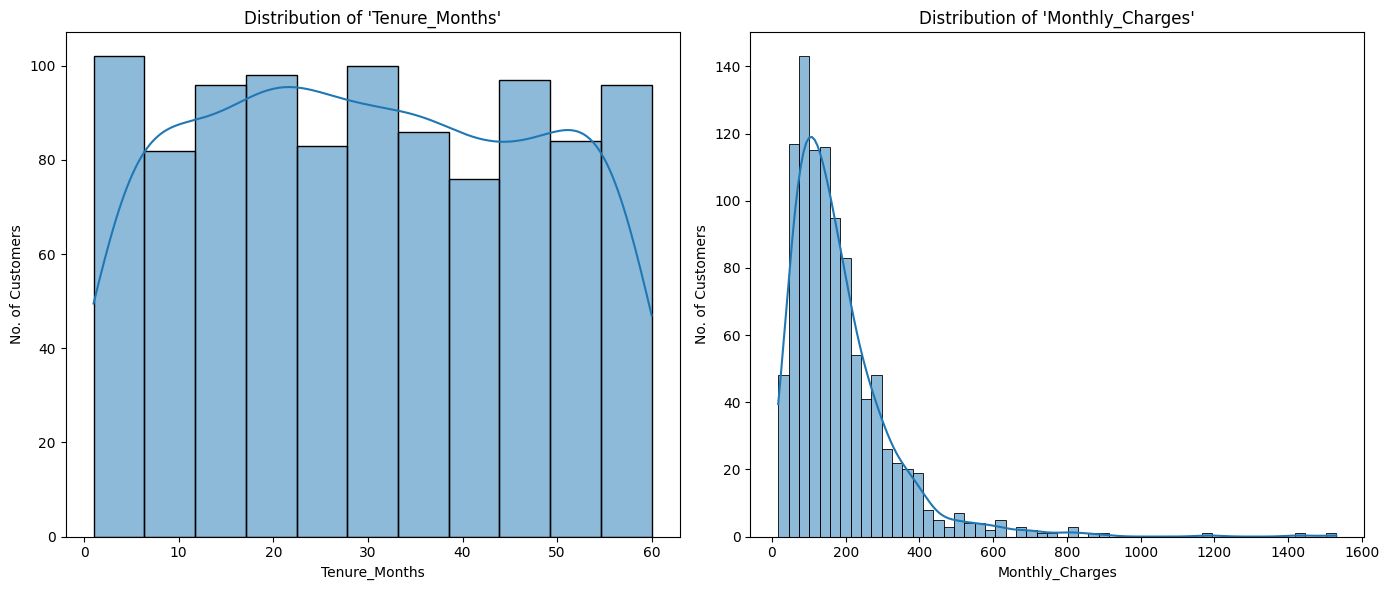

In [33]:
# Individual Histograms of Numerical_Columns/ Independant_Variables/ Feature_Columns

# Numerical_Columns/ Independant_Variables/ Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]

Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]

# "Tenure_Months"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.histplot(data = data, x = "Tenure_Months", kde = True)

plt.title("Distribution of 'Tenure_Months'")
plt.xlabel("Tenure_Months")
plt.ylabel("No. of Customers")

# "Monthly_Charges"

plt.subplot(1,2,2)
sns.histplot(data = data, x = "Monthly_Charges", kde = True)

plt.title("Distribution of 'Monthly_Charges'")
plt.xlabel("Monthly_Charges")
plt.ylabel("No. of Customers")

plt.tight_layout()
plt.show()



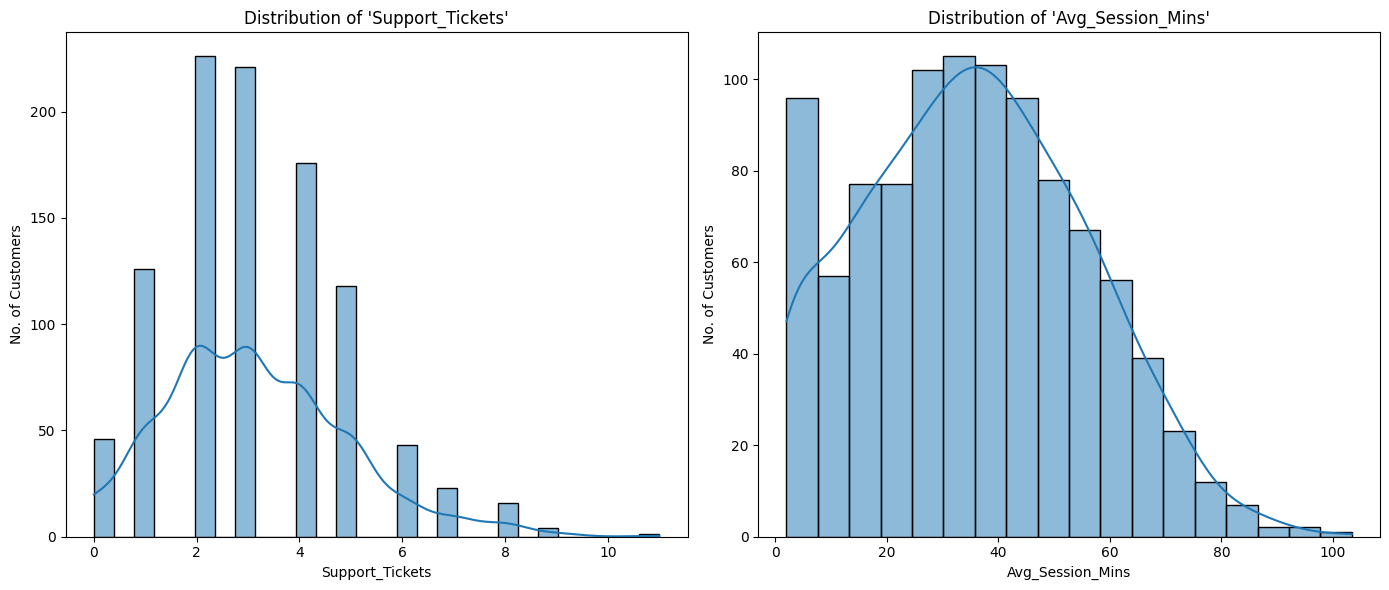

In [34]:
# "Support_Tickets"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.histplot(data = data, x = "Support_Tickets", kde = True)

plt.title("Distribution of 'Support_Tickets'")
plt.xlabel("Support_Tickets")
plt.ylabel("No. of Customers")

# "Avg_Session_Mins"

plt.subplot(1,2,2)
sns.histplot(data = data, x = "Avg_Session_Mins", kde = True)

plt.title("Distribution of 'Avg_Session_Mins'")
plt.xlabel("Avg_Session_Mins")
plt.ylabel("No. of Customers")

plt.tight_layout()
plt.show()

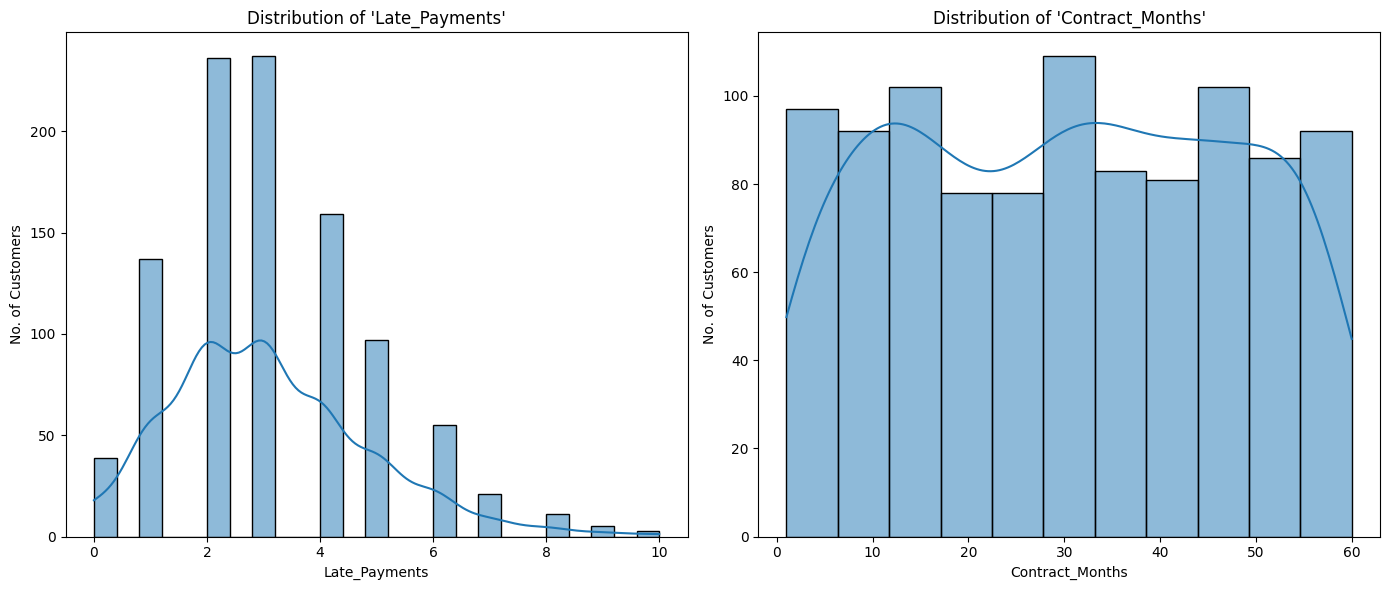

In [35]:
# "Late_Payments"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.histplot(data = data, x = "Late_Payments", kde = True)

plt.title("Distribution of 'Late_Payments'")
plt.xlabel("Late_Payments")
plt.ylabel("No. of Customers")

# "Contract_Months"

plt.subplot(1,2,2)
sns.histplot(data = data, x = "Contract_Months", kde = True)

plt.title("Distribution of 'Contract_Months'")
plt.xlabel("Contract_Months")
plt.ylabel("No. of Customers")

plt.tight_layout()
plt.show()

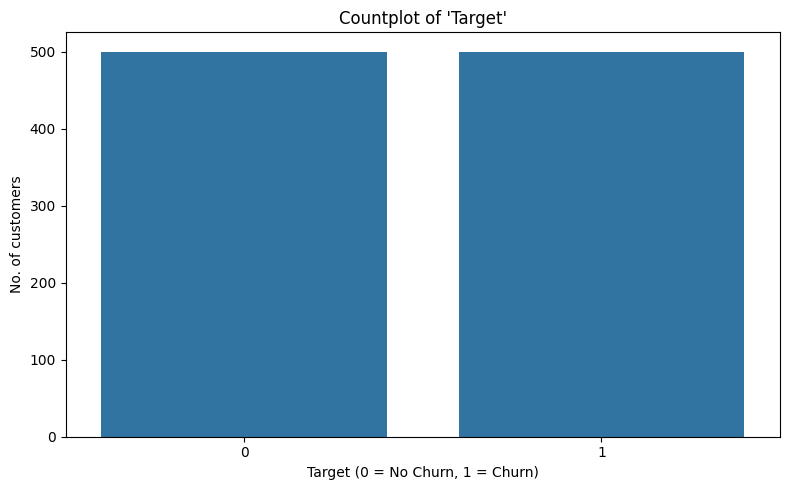

In [36]:
# Countplot for 'Target'

# Categorical_Columns/ Dependant Variable = ["Target"]

Categorical_Columns = ["Target"]

plt.figure(figsize = (8,5))

sns.countplot(data = data, x = "Target")

plt.title("Countplot of 'Target'")
plt.xlabel("Target (0 = No Churn, 1 = Churn)")
plt.ylabel  ("No. of customers")

plt.tight_layout()
plt.show()

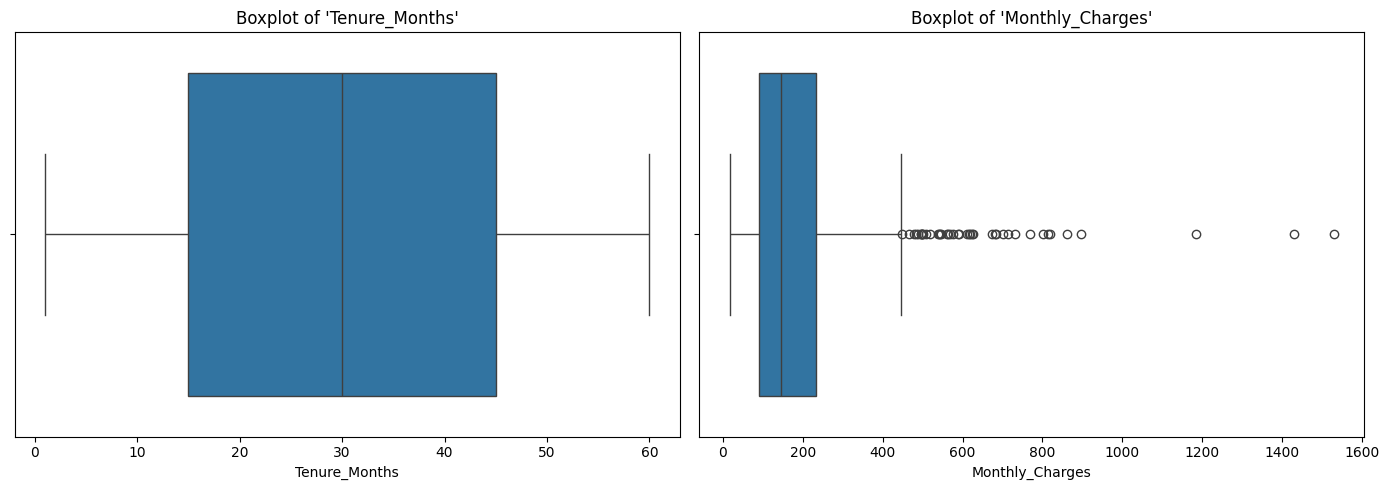

In [37]:
# Boxplots (Individual Boxplots for Independant_Features/ Numerical_Columns/ Feature_Columns)

# Numerical_Columns/ Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]
# Categorical_Columns/ Dependant Variable = ["Target"]

Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]
Categorical_Columns = ["Target"]

# "Tenure_Months"

plt.figure(figsize = (14,5))

plt.subplot(1, 2, 1)
sns.boxplot(x = data["Tenure_Months"])

plt.title("Boxplot of 'Tenure_Months'")
plt.xlabel("Tenure_Months")

# "Monthly_Charges"

plt.subplot(1, 2, 2)
sns.boxplot(x = data["Monthly_Charges"])

plt.title("Boxplot of 'Monthly_Charges'")
plt.xlabel("Monthly_Charges")

plt.tight_layout()
plt.show()



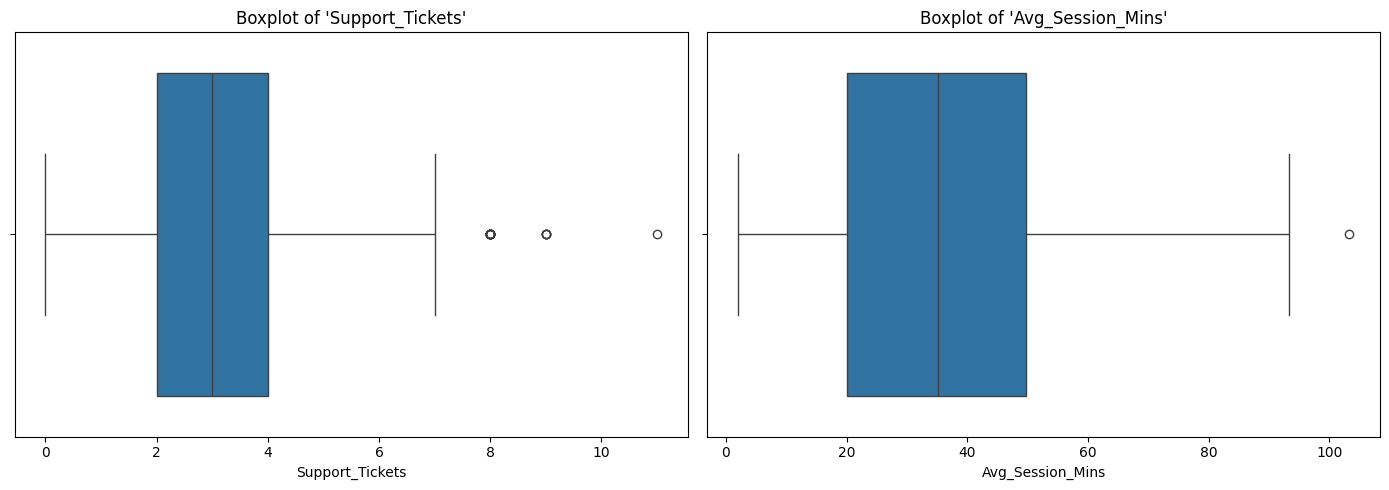

In [38]:
# "Support_Tickets"

plt.figure(figsize = (14,5))

plt.subplot(1, 2, 1)
sns.boxplot(x = data["Support_Tickets"])

plt.title("Boxplot of 'Support_Tickets'")
plt.xlabel("Support_Tickets")

# "Avg_Session_Mins"

plt.subplot(1, 2, 2)
sns.boxplot(x = data["Avg_Session_Mins"])

plt.title("Boxplot of 'Avg_Session_Mins'")
plt.xlabel("Avg_Session_Mins")

plt.tight_layout()
plt.show()

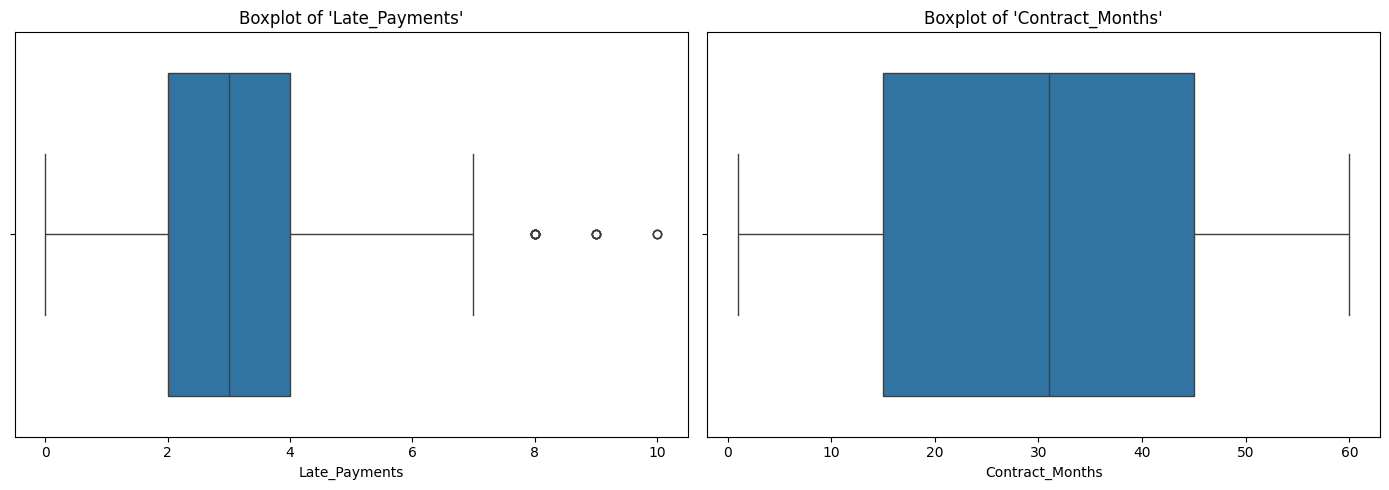

In [39]:
# "Late_Payments"

plt.figure(figsize = (14,5))

plt.subplot(1, 2, 1)
sns.boxplot(x = data["Late_Payments"])

plt.title("Boxplot of 'Late_Payments'")
plt.xlabel("Late_Payments")

# "Contract_Months"

plt.subplot(1, 2, 2)
sns.boxplot(x = data["Contract_Months"])

plt.title("Boxplot of 'Contract_Months'")
plt.xlabel("Contract_Months")

plt.tight_layout()
plt.show()

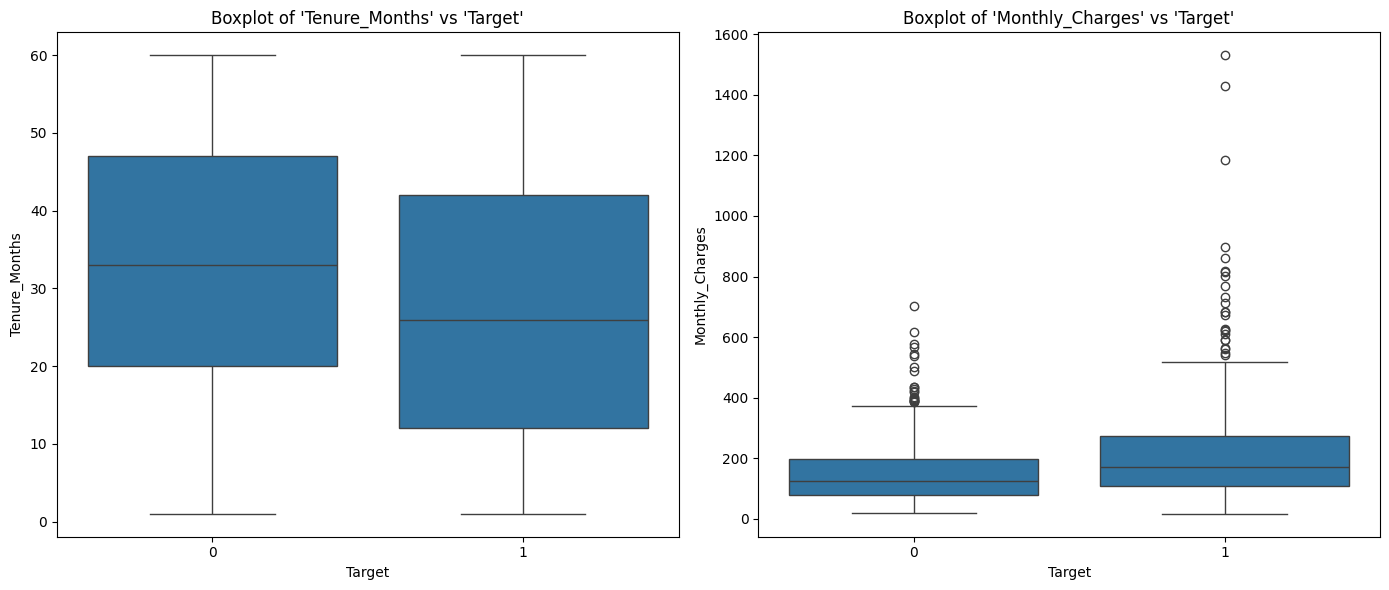

In [40]:
# Boxplot distribution w.r.t Independant Features/ Numerical_Columns/ Feature_Columns and Dependant Features/ Cateogorical Columns

# Numerical_Columns/ Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]
# Categorical_Columns/ Dependant Variable = ["Target"]

Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]
Categorical_Columns = ["Target"]

# "Tenure_Months" vs "Target"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.boxplot(data = data, x = "Target", y = "Tenure_Months")

plt.title("Boxplot of 'Tenure_Months' vs 'Target'")
plt.xlabel("Target")
plt.ylabel("Tenure_Months")

# "Monthly_Charges" vs "Target"

plt.subplot(1,2,2)
sns.boxplot(data = data, x = "Target", y = "Monthly_Charges")

plt.title("Boxplot of 'Monthly_Charges' vs 'Target'")
plt.xlabel("Target")
plt.ylabel("Monthly_Charges")

plt.tight_layout()
plt.show()

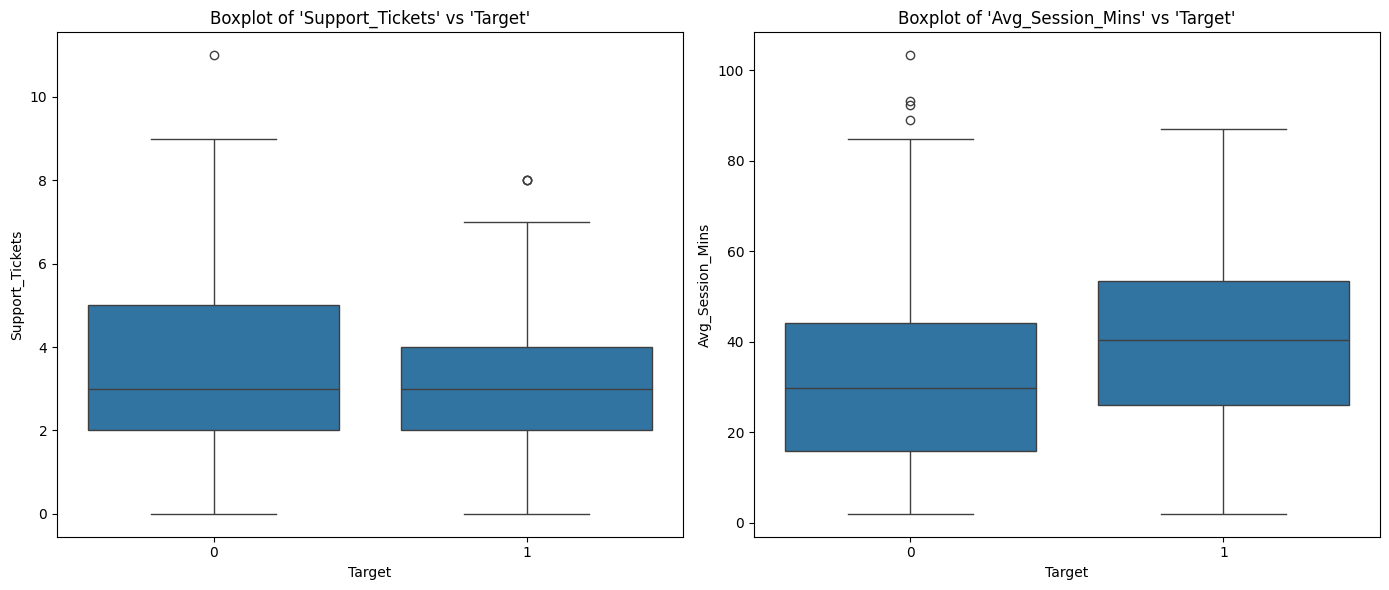

In [41]:
# "Support_Tickets" vs "Target"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.boxplot(data = data, x = "Target", y = "Support_Tickets")

plt.title("Boxplot of 'Support_Tickets' vs 'Target'")
plt.xlabel("Target")
plt.ylabel("Support_Tickets")

# "Avg_Session_Mins" vs "Target"

plt.subplot(1,2,2)
sns.boxplot(data = data, x = "Target", y = "Avg_Session_Mins")

plt.title("Boxplot of 'Avg_Session_Mins' vs 'Target'")
plt.xlabel("Target")
plt.ylabel("Avg_Session_Mins")

plt.tight_layout()
plt.show()

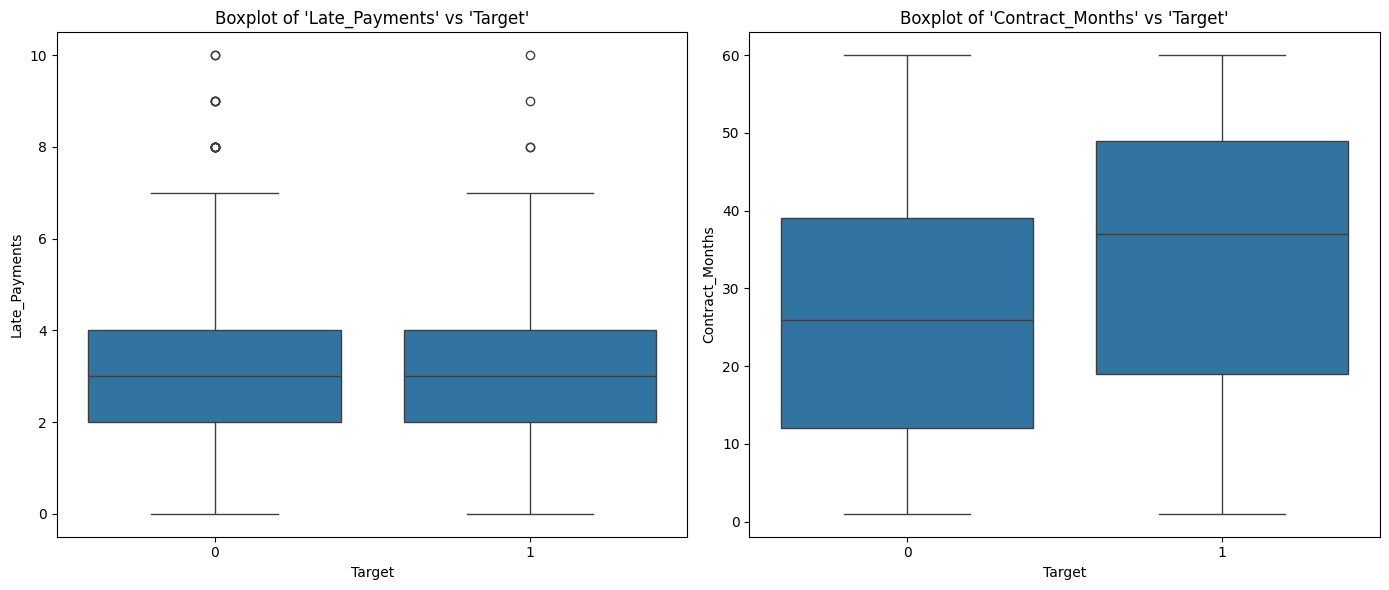

In [42]:
# "Late_Payments" vs "Target"

plt.figure(figsize = (14,6))

plt.subplot(1,2,1)
sns.boxplot(data = data, x = "Target", y = "Late_Payments")

plt.title("Boxplot of 'Late_Payments' vs 'Target'")
plt.xlabel("Target")
plt.ylabel("Late_Payments")

# "Contract_Months" vs "Target"

plt.subplot(1,2,2)
sns.boxplot(data = data, x = "Target", y = "Contract_Months")

plt.title("Boxplot of 'Contract_Months' vs 'Target'")
plt.xlabel("Target")
plt.ylabel("Contract_Months")

plt.tight_layout()
plt.show()

In [43]:
# All averages w.r.t Dependant_Features/ Target_Variables/ Categorical_Columns

pd.set_option("display.width", 200)
print(data.groupby("Target")[Feature_Columns].mean())

        Tenure_Months  Monthly_Charges  Support_Tickets  Avg_Session_Mins  Late_Payments  Contract_Months
Target                                                                                                   
0              32.858        151.23758            3.496          31.34468          3.378           26.760
1              27.384        214.23896            2.762          39.67822          2.784           33.708


In [44]:
# Correlation Matrix & Heatmap

correlation_matrix = data.corr(numeric_only = True)

correlation_matrix

,Tenure_Months,Monthly_Charges,Support_Tickets,Avg_Session_Mins,Late_Payments,Contract_Months,Target
Tenure_Months,1.000000,-0.041690,-0.007434,-0.001270,-0.008596,-0.043690,-0.159055
Monthly_Charges,-0.041690,1.000000,-0.067352,0.002571,0.023558,-0.006257,0.217740
Support_Tickets,-0.007434,-0.067352,1.000000,0.003537,0.023869,0.001140,-0.207164
Avg_Session_Mins,-0.001270,0.002571,0.003537,1.000000,0.030675,-0.008764,0.208914
Late_Payments,-0.008596,0.023558,0.023869,0.030675,1.000000,-0.055778,-0.168456
Contract_Months,-0.043690,-0.006257,0.001140,-0.008764,-0.055778,1.000000,0.201443
Target,-0.159055,0.217740,-0.207164,0.208914,-0.168456,0.201443,1.000000


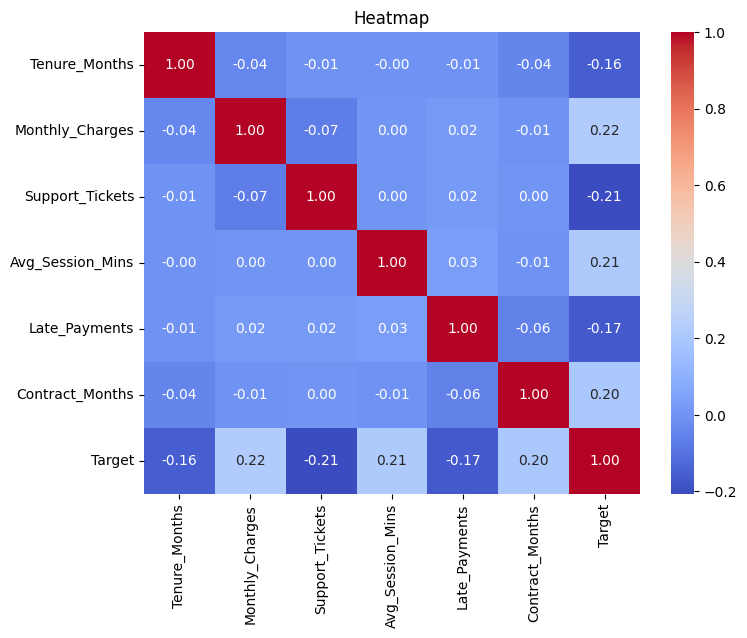

In [45]:
# Creating Heatmap for the Correlation Matrix

plt.figure(figsize = (8,6))

sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")

plt.title("Heatmap")

plt.show()

In [46]:
# Splitting the dataset

# Seperate into input & output variables (i.e) independant features & dependant features (i.e) X & y

# X = Numerical_Columns/ Feature_Columns = ["Tenure_Months", "Monthly_Charges", "Support_Tickets", "Avg_Session_Mins", "Late_Payments", "Contract_Months"]
# y = Categorical_Columns/ Dependant Variable = ["Target"]

# Or,

X = data.drop("Target", axis = 1)

y = data["Target"]

In [47]:
X

,Tenure_Months,Monthly_Charges,Support_Tickets,Avg_Session_Mins,Late_Payments,Contract_Months
0,52,54.79,7,10.66,2,12
1,11,167.15,4,46.99,3,37
2,2,184.92,3,65.38,7,35
3,39,271.21,2,22.19,4,10
4,22,66.33,5,46.77,3,33
...,...,...,...,...,...,...
995,21,84.05,3,33.59,4,10
996,22,275.85,1,53.71,3,19
997,7,113.44,0,72.04,1,48
998,21,242.63,4,53.20,5,39


In [48]:
y

,Target
0,0
1,1
2,1
3,0
4,1
...,...
995,1
996,1
997,1
998,0


In [49]:
# Shape of X & y

print(X.shape)
print(y.shape)
print("Features:", X.columns.to_list())
print("Target:", y.name)

(1000, 6)
(1000,)
Features: ['Tenure_Months', 'Monthly_Charges', 'Support_Tickets', 'Avg_Session_Mins', 'Late_Payments', 'Contract_Months']
Target: Target


In [50]:
# Train - Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 800
Testing Rows: 200


In [51]:
# Scaling - Scale the features

# Logistic Regression is sensitive to feature scale. Fit the scale only on training data to avoid data leakage.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled.")

Features have been scaled.


In [53]:
# Train the model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state = 42, max_iter = 1000)
model.fit(X_train_scaled, y_train)

print("Model has been trained.")

Model has been trained.


In [54]:
# Make predictions

y_pred = model.predict(X_test_scaled)

print("First 20 predictions:", y_pred[:20])

First 20 predictions: [1 1 0 0 1 1 0 1 1 0 0 1 1 0 0 0 1 0 1 0]


In [55]:
# Evaluation Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.68
Precision: 0.6837
Recall: 0.67
F1 Score: 0.6768


In [56]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(confusion_matrix)

Confusion Matrix:

[[69 31]
 [33 67]]


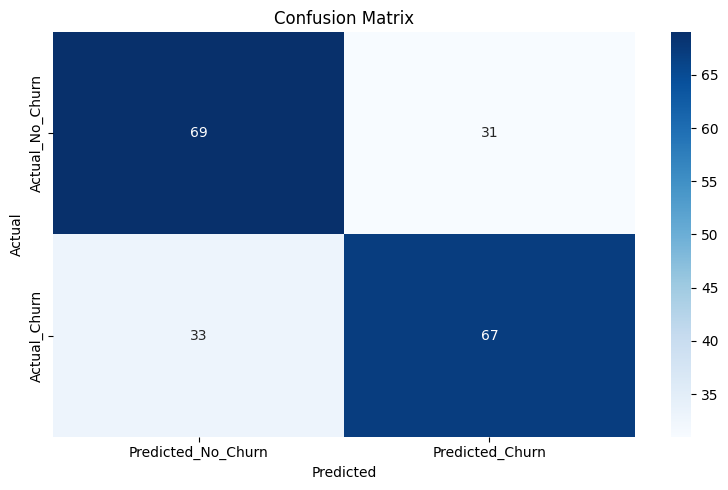

In [57]:
# Plotting the Confusion_Matrix

plt.figure(figsize = (8,5))

sns.heatmap(confusion_matrix, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = ["Predicted_No_Churn", "Predicted_Churn"],
            yticklabels = ["Actual_No_Churn", "Actual_Churn"])

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [58]:
# Reading the Confusion_Matrix

# True Negative: Actual 0, Predicted 0
# False Positive: Actual 0, Predicted 1
# False Negative: Actual 1, Predicted 0
# True Positive: Actual 1, Predicted 1

# False Negatives can be important in Churn Prediction because there are customers who churned but were not identified.

In [59]:
# Classification_Report

from sklearn.metrics import classification_report

print("Classification_Report:\n")
print(classification_report(y_test, y_pred, target_names = ["No_Churn", "Churn"]))

Classification_Report:

              precision    recall  f1-score   support

    No_Churn       0.68      0.69      0.68       100
       Churn       0.68      0.67      0.68       100

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.68      0.68       200



In [60]:
# Observations

# The model is balanced — performance is nearly identical for both classes. That’s good, because churn datasets often suffer from imbalance.
# However, 0.68 accuracy is moderate. It’s better than random guessing (which would be ~0.50), but not strong enough for production use if churn prediction is critical.

In [61]:
# Interpret Logistic Regression Coefficients -

# Positive Coefficient - Associated with higher churn risk.
# Negative Coefficient - Associated with lower churn risk.

# Because features were standardized, coefficients are easier to compare.

In [62]:
coefficients = pd.DataFrame({"Feature": Feature_Columns, "Coefficient": model.coef_[0]})

coefficients["Absolute Coefficient Value"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by = "Absolute Coefficient Value", ascending = False)

print("Coefficients:\n\n", coefficients)

Coefficients:

             Feature  Coefficient  Absolute Coefficient Value
1   Monthly_Charges     0.646803                    0.646803
5   Contract_Months     0.536243                    0.536243
3  Avg_Session_Mins     0.508222                    0.508222
2   Support_Tickets    -0.447767                    0.447767
4     Late_Payments    -0.428239                    0.428239
0     Tenure_Months    -0.351499                    0.351499


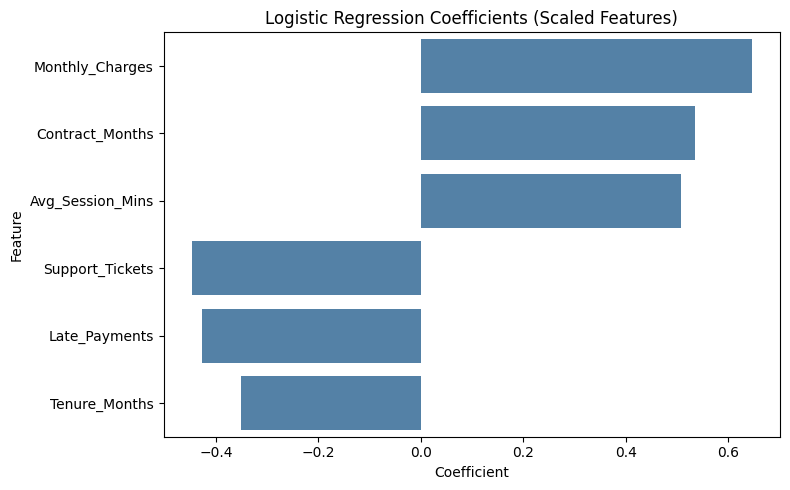

In [63]:
# Plot the Coefficients

plt.figure(figsize = (8,5))

sns.barplot(data = coefficients, x = "Coefficient", y = "Feature", color = "steelblue")

plt.title("Logistic Regression Coefficients (Scaled Features)")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [64]:
# A +ve Coefficient means that as the feature value increases, the customer is more likely to churn (log odds of churn go up).
# A -ve Coefficient means that as the feature value increases, the customer is less likely to churn.

In [65]:
# Limitations:

# 1. Synthetic data: This dataset is artificially generated for practice, so the relationships between features and churn may be simpler/cleaner than in real customer data.
# 2. Linearity assumption: Logistic Regression assumes a linear relationship between features (after scaling) and the log-odds of the outcome. Real churn behavior may involve more complex, non-linear interactions that this model cannot capture.
# 3. Limited features: Only 6 features are available. Real churn models often use dozens of features (e.g. usage trends over time, customer service sentiment, competitor pricing).
# 4. Single train/test split: Results can vary depending on how the data happens to be split. Using cross-validation (cross_val_score) would give a more robust estimate of performance.

# Possible improvements:

# 1. Try cross-validation instead of a single split.
# 2. Try regularization strength tuning (C parameter) via GridSearchCV.
# 3. Compare against other models (e.g. Random Forest, Gradient Boosting) as a benchmark.
# 4. Collect more/richer features if this were a real business use case.

In [66]:
# Conclusions

# The Logistic Regression model gives a reproducible, interpretable baseline for predicting customer churn risk.

# Its coefficients offer a simple explanation of which factors are associated with churn, making it a good first model to try before investing in
# more complex approaches — as long as its assumptions and limitations (above) are kept in mind.